# Materi 2: Representasi Kata dalam NLP


## Ringkasan Teori

Komputer nggak ngerti teks kayak manusia, jadi teks harus diubah jadi angka dulu biar bisa diolah. Ada beberapa cara yang berkembang dari waktu ke waktu:

### 1. One-Hot Encoding
Cara paling dasar. Tiap kata direpresentasikan sebagai vektor panjang berisi angka 0, kecuali di posisi kata tersebut yang bernilai 1.
- **Kelemahan:** Boros memori kalau kosakatanya banyak (*Curse of Dimensionality*), dan model nggak tahu kalau "sepak bola" dan "futsal" itu mirip (nggak ada hubungan semantik).

### 2. Bag-of-Words (BOW)
Cuma ngitung berapa kali setiap kata muncul di dokumen, tanpa peduli urutan katanya.
- **Kelemahan:** Kata hubung seperti "dan", "yang", "di" sering muncul tapi nggak punya makna penting, jadi skornya malah tinggi.

### 3. TF-IDF (Term Frequency - Inverse Document Frequency)
Upgrade dari BOW. Kata yang sering muncul di banyak dokumen (kayak kata hubung) dikasih penalti bobotnya, sehingga kata yang benar-benar unik dan spesifik per dokumen dapat skor lebih tinggi.

### 4. Word Embeddings & Reduksi Dimensi
Untuk ngatasin dimensi yang besar, dikembangkan representasi yang lebih padat (dense). Ada dua pendekatan:
- **Neural Network:** Seperti Word2Vec (Skip-Gram/CBOW) yang mempelajari konteks kalimat.
- **SVD / Matrix Factorization:** Mereduksi matriks TF-IDF jadi dimensi yang lebih kecil. Di praktik kita pakai turunannya yaitu **PCA**.

---

# Tugas Materi 2: Text Preprocessing & Representasi Vektor

Lanjutan dari Materi 1, di sini kita bakal olah data berita yang udah di-crawl dan disimpen di `output/crawling_detik.csv`.

Alurnya:
1. **Load Data** dari CSV.
2. **Text Cleaning:** Hapus tanda baca, angka, dan lowercasing.
3. **Standardisasi Kata Tidak Baku** (slang).
4. **Stopword Removal:** Hapus kata-kata umum yang nggak informatif.
5. **Hitung Kata Unik** dan ekspor ke CSV.
6. **TF-IDF:** Representasikan dokumen sebagai vektor angka.
7. **PCA:** Kurangi dimensi TF-IDF biar lebih efisien.

### Langkah 1: Load Data CSV

In [1]:
import pandas as pd

df = pd.DataFrame()
try:
    df = pd.read_csv('output/crawling_detik.csv')
    print(f"Data berhasil dimuat! Total baris: {len(df)}")
    print(f"Distribusi label:\n{df['Label'].value_counts()}")
except FileNotFoundError:
    print("File belum ada. Jalankan materi1.ipynb dulu ya!")

display(df.head())

Data berhasil dimuat! Total baris: 200
Distribusi label:
Label
sport      100
finance    100
Name: count, dtype: int64


,ID,Isi Berita,Label
0,1,Lombok - Sejumlah pekerja melakukan pengecatan...,sport
1,2,Nagoya - Sejumlah jurnalis beraktivitas di Mai...,sport
2,3,Pebalap Spanyol David Almansa jadi yang tercep...,sport
3,4,Pebalap KTM Pedro Acosta mendominasi Free Prac...,sport
4,5,Rider Spanyol David Almansa kembali jadi yang ...,sport


### Langkah 2: Text Cleaning

In [2]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Ubah semua huruf jadi kecil
    text = text.lower()
    # Hapus semua karakter selain huruf a-z dan spasi
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Bersihkan spasi yang berlebihan
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if not df.empty:
    df['Teks Bersih'] = df['Isi Berita'].apply(clean_text)
    print("Contoh hasil cleaning:")
    display(df[['Isi Berita', 'Teks Bersih']].head(3))

Contoh hasil cleaning:


,Isi Berita,Teks Bersih
0,Lombok - Sejumlah pekerja melakukan pengecatan...,lombok sejumlah pekerja melakukan pengecatan l...
1,Nagoya - Sejumlah jurnalis beraktivitas di Mai...,nagoya sejumlah jurnalis beraktivitas di main ...
2,Pebalap Spanyol David Almansa jadi yang tercep...,pebalap spanyol david almansa jadi yang tercep...


### Langkah 3: Standardisasi Kata Tidak Baku

In [3]:
# Kamus kata tidak baku -> baku
slang_dict = {
    'tdk': 'tidak', 'yg': 'yang', 'dgn': 'dengan',
    'jd': 'jadi', 'kalo': 'kalau', 'nggak': 'tidak',
    'gak': 'tidak', 'udah': 'sudah', 'bgt': 'banget',
    'utk': 'untuk', 'krn': 'karena', 'dr': 'dari',
    'tsb': 'tersebut', 'pd': 'pada', 'sdh': 'sudah'
}

def standardize_slang(text):
    return ' '.join([slang_dict.get(w, w) for w in text.split()])

if not df.empty:
    df['Teks Standard'] = df['Teks Bersih'].apply(standardize_slang)
    print("Standardisasi selesai!")

Standardisasi selesai!


### Langkah 4: Stopword Removal

Hapus kata-kata yang sering muncul tapi nggak membawa makna penting (kata hubung, preposisi, dsb). Ini penting agar representasi TF-IDF kita lebih fokus ke kata-kata yang benar-benar relevan.

In [4]:
# Daftar stopword Bahasa Indonesia
stopwords_id = [
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan',
    'untuk', 'adalah', 'ada', 'tidak', 'juga', 'pada', 'dalam',
    'akan', 'karena', 'oleh', 'sudah', 'atau', 'saat', 'bisa',
    'jadi', 'telah', 'seperti', 'sehingga', 'dapat', 'agar',
    'kami', 'kita', 'ia', 'nya', 'lebih', 'sangat', 'pun',
    'namun', 'maka', 'kalau', 'jika', 'bila', 'saja', 'bagi',
    'demi', 'walau', 'meski', 'tetapi', 'tapi', 'namun',
    'hal', 'cara', 'atas', 'bawah', 'antara', 'tanpa',
    'tahun', 'hari', 'yang', 'pun', 'lagi'
]

def remove_stopwords(text):
    return ' '.join([w for w in text.split() if w not in stopwords_id])

if not df.empty:
    df['Teks Final'] = df['Teks Standard'].apply(remove_stopwords)
    print("Stopword removal selesai!")
    print("\nContoh sebelum vs sesudah stopword removal:")
    display(df[['Teks Standard', 'Teks Final']].head(3))

Stopword removal selesai!

Contoh sebelum vs sesudah stopword removal:


,Teks Standard,Teks Final
0,lombok sejumlah pekerja melakukan pengecatan l...,lombok sejumlah pekerja melakukan pengecatan l...
1,nagoya sejumlah jurnalis beraktivitas di main ...,nagoya sejumlah jurnalis beraktivitas main pre...
2,pebalap spanyol david almansa jadi yang tercep...,pebalap spanyol david almansa tercepat free pr...


### Langkah 5: Hitung & Ekspor Kata Unik

In [5]:
import os

if not df.empty:
    semua_kata = []
    for teks in df['Teks Final']:
        semua_kata.extend(teks.split())

    jumlah_total_kata = len(semua_kata)
    kata_unik = sorted(list(set(semua_kata)))
    jumlah_kata_unik = len(kata_unik)

    print(f"Total kata keseluruhan  : {jumlah_total_kata:,} kata")
    print(f"Jumlah kata unik         : {jumlah_kata_unik:,} kata")

    os.makedirs('output', exist_ok=True)
    df_unik = pd.DataFrame({'Kata Unik': kata_unik})
    df_unik.to_csv('output/kata_unik.csv', index=False)

    # Hitung frekuensi tiap kata
    from collections import Counter
    freq = Counter(semua_kata)
    df_freq = pd.DataFrame(freq.most_common(20), columns=['Kata', 'Frekuensi'])

    print("\n20 Kata paling sering muncul:")
    display(df_freq)
    print("\nFile 'kata_unik.csv' sudah tersimpan di folder output!")

Total kata keseluruhan  : 45,136 kata
Jumlah kata unik         : 7,262 kata

20 Kata paling sering muncul:


,Kata,Frekuensi
0,indonesia,292
1,tersebut,285
2,menjadi,263
3,rp,228
4,emas,225
5,saya,214
6,satu,146
7,tim,145
8,hingga,143
9,sebagai,141



File 'kata_unik.csv' sudah tersimpan di folder output!


### Langkah 6: TF-IDF (Term Frequency - Inverse Document Frequency)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

if not df.empty:
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(df['Teks Final'])

    print(f"Ukuran matriks TF-IDF  : {tfidf_matrix.shape}")
    print(f"  -> {tfidf_matrix.shape[0]} dokumen")
    print(f"  -> {tfidf_matrix.shape[1]} fitur (kata unik)")

    # Simpan ke CSV
    df_tfidf = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=vectorizer.get_feature_names_out()
    )
    df_tfidf['Label'] = df['Label'].values
    df_tfidf.to_csv('output/tfidf.csv', index=False)
    print("\nFile 'tfidf.csv' sudah tersimpan di folder output!")

Ukuran matriks TF-IDF  : (200, 7239)
  -> 200 dokumen
  -> 7239 fitur (kata unik)

File 'tfidf.csv' sudah tersimpan di folder output!


### Langkah 7: Reduksi Dimensi dengan PCA

Matriks TF-IDF kita punya ribuan kolom — terlalu berat buat model klasifikasi. PCA mereduksi dimensi ini ke yang paling penting saja.

Komponen yang dibutuhkan untuk 95% variansi: 165


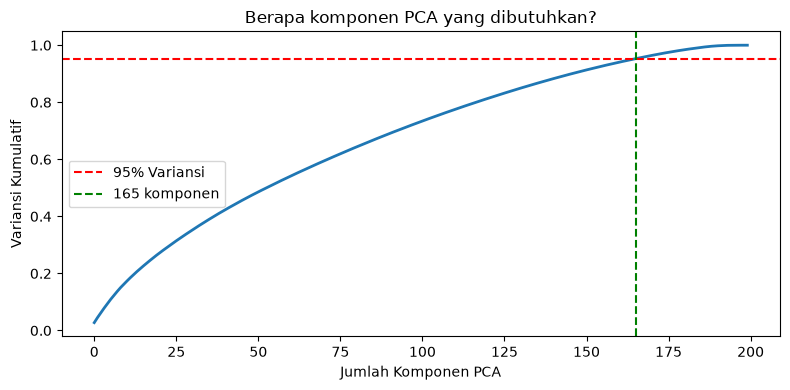

File 'pca.csv' sudah tersimpan (165 komponen + kolom Label)!


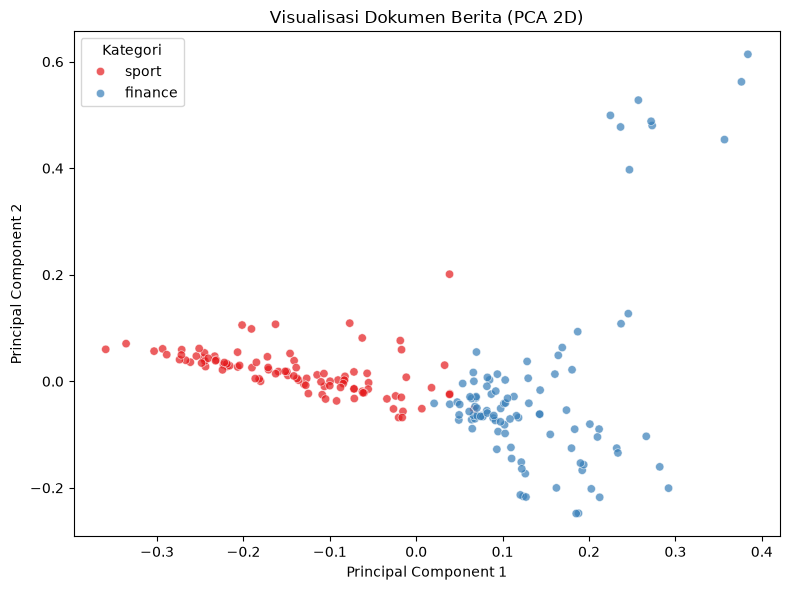

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if not df.empty:
    dense_matrix = tfidf_matrix.toarray()

    # Cari jumlah komponen yang menangkap minimal 95% variansi
    pca_full = PCA()
    pca_full.fit(dense_matrix)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_components_95 = np.argmax(cumvar >= 0.95) + 1
    print(f"Komponen yang dibutuhkan untuk 95% variansi: {n_components_95}")

    # Plot kurva variansi kumulatif
    plt.figure(figsize=(8, 4))
    plt.plot(cumvar, linewidth=2)
    plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variansi')
    plt.axvline(x=n_components_95, color='green', linestyle='--', label=f'{n_components_95} komponen')
    plt.xlabel('Jumlah Komponen PCA')
    plt.ylabel('Variansi Kumulatif')
    plt.title('Berapa komponen PCA yang dibutuhkan?')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Terapkan PCA dengan n_components = n_components_95
    pca = PCA(n_components=n_components_95, random_state=42)
    pca_result = pca.fit_transform(dense_matrix)

    # Simpan ke DataFrame
    col_names = [f'PC{i+1}' for i in range(n_components_95)]
    df_pca = pd.DataFrame(pca_result, columns=col_names)
    df_pca['Label'] = df['Label'].values
    df_pca.to_csv('output/pca.csv', index=False)
    print(f"File 'pca.csv' sudah tersimpan ({n_components_95} komponen + kolom Label)!")

    # Visualisasi 2D dengan PC1 & PC2
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette='Set1', alpha=0.7)
    plt.title('Visualisasi Dokumen Berita (PCA 2D)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Kategori')
    plt.tight_layout()
    plt.show()